In [ ]:
# Core libraries for file handling, math, visualization, and data manipulation
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json

# USD Torero Theme Colors (consistent branding across all plots)
COLOR_TRUE = "#00205B"      # Torero Blue — true positions
COLOR_PRED = "#6BAED6"      # Light Blue — predicted positions
COLOR_BASELINE = "#C5A100"  # Gold — baseline model
COLOR_GRU = "#4D4D4D"       # Neutral Gray — GRU model
COLOR_LSTM = "#6BAED6"      # Light Blue — LSTM model
COLOR_TCN = "#00205B"       # Dark Torero Blue — TCN model

# Global seaborn theme
sns.set_theme(style="whitegrid")

# Global matplotlib font sizes for consistent styling
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["xtick.labelsize"] = 13
plt.rcParams["ytick.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 13
plt.rcParams["figure.figsize"] = (10, 6)

# Models included in the visualization suite
MODELS = ["GRU", "LSTM", "TCN"]
FUTURE_STEPS = 5

print("USD Visualization Notebook Initialized.")


USD Visualization Notebook Initialized.


In [ ]:
# Notebook runs from: Capstone_Group16/notebooks/
# Artifacts live in:  Capstone_Group16/src/artifacts/

# Build absolute paths to artifact directories
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "src"))
ARTIFACT_DIR = os.path.join(BASE_DIR, "artifacts")

# Subdirectories for predictions, losses, metrics, and window diagnostics
PRED_DIR = os.path.join(ARTIFACT_DIR, "predictions")
LOSS_DIR = os.path.join(ARTIFACT_DIR, "loss")
METRIC_DIR = os.path.join(ARTIFACT_DIR, "metrics")
WINDOW_DIR = os.path.join(ARTIFACT_DIR, "windows")

print("Artifacts directory:", ARTIFACT_DIR)


Artifacts directory: C:\Users\gb630\OneDrive\USD AAI\USD AAI\AAI-590 CAPSTONE\Capstone_Group16\src\artifacts


In [ ]:
def load_loss_curve(model_name):
    """
    Load the training loss curve for a given model.
    Stored as a NumPy array in src/artifacts/loss/.
    """
    return np.load(os.path.join(LOSS_DIR, f"{model_name}_loss.npy"))

def load_predictions(model_name, phase):
    """
    Load predictions and targets for a given model + phase.
    Phase is typically 'VAL' or 'TEST'.
    """
    preds = np.load(os.path.join(PRED_DIR, f"{model_name}_{phase}_preds.npy"))
    targets = np.load(os.path.join(PRED_DIR, f"{model_name}_{phase}_targets.npy"))
    return preds, targets

print("Loaders ready.")


Loaders ready.


#### RESULTS SECTION PLOTS
=============================

In [ ]:
def plot_all_loss_curves():
    """
    Plot early training loss curves for GRU, LSTM, and TCN.
    Focuses on the first ~500 batches where convergence behavior is visible.
    """
    plt.figure(figsize=(12, 6))

    for model in MODELS:
        loss = load_loss_curve(model)
        color = {
            "Baseline": COLOR_BASELINE,
            "GRU": COLOR_GRU,
            "LSTM": COLOR_LSTM,
            "TCN": COLOR_TCN
        }[model]

        # Zoom into first 500 batches to highlight convergence
        plt.plot(loss[:500], label=model, linewidth=2.5, color=color)

    plt.title("Training Loss Curves (Early Convergence Region)")
    plt.xlabel("Batch Number")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

print("Loss curve function ready.")


Loss curve function ready.


In [ ]:
def plot_all_error_distributions(phase="TEST"):
    """
    Plot kernel density estimates of displacement errors for all models.
    Shows how error magnitudes are distributed across the dataset.
    """
    plt.figure(figsize=(12, 6))

    for model in MODELS:
        preds, targets = load_predictions(model, phase)
        errors = np.linalg.norm(preds - targets, axis=2).flatten()

        color = {
            "Baseline": COLOR_BASELINE,
            "GRU": COLOR_GRU,
            "LSTM": COLOR_LSTM,
            "TCN": COLOR_TCN
        }[model]

        sns.kdeplot(errors, label=model, color=color, linewidth=2)

    plt.title(f"Error Distributions for All Models ({phase})")
    plt.xlabel("Displacement Error (meters)")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

print("Combined error distribution function ready.")


Combined error distribution function ready.


In [ ]:
def plot_all_scatter_final_displacements(phase="TEST"):
    """
    Scatter plot of predicted final displacements for all models.
    True final position is always (0,0) in displacement space.
    """
    plt.figure(figsize=(10, 10))

    for model in MODELS:
        preds, targets = load_predictions(model, phase)

        color = {
            "Baseline": COLOR_BASELINE,
            "GRU": COLOR_GRU,
            "LSTM": COLOR_LSTM,
            "TCN": COLOR_TCN
        }[model]

        plt.scatter(
            preds[:, -1, 0], preds[:, -1, 1],
            s=40, alpha=0.6, label=model, color=color
        )

    # True final displacement is always zero
    plt.scatter([0], [0], s=120, color=COLOR_TRUE, label="True Final Position")

    plt.title(f"Predicted vs True Final Displacements ({phase})")
    plt.xlabel("X Displacement (meters)")
    plt.ylabel("Y Displacement (meters)")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.legend()
    plt.tight_layout()
    plt.show()

print("Combined scatter function ready.")


Combined scatter function ready.


In [ ]:
def plot_loss_curve_individual(model):
    """
    Plot full training loss curve for a single model.
    """
    loss = load_loss_curve(model)
    plt.figure()
    plt.plot(loss, linewidth=2.5, color=COLOR_TCN)
    plt.title(f"Training Loss Curve: {model}")
    plt.xlabel("Batch Number")
    plt.ylabel("Loss")
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_error_distribution_individual(model, phase="TEST"):
    """
    Histogram + KDE of displacement errors for a single model.
    """
    preds, targets = load_predictions(model, phase)
    errors = np.linalg.norm(preds - targets, axis=2).flatten()

    plt.figure()
    sns.histplot(errors, bins=40, kde=True, color=COLOR_TCN)
    plt.title(f"Error Distribution: {model} ({phase})")
    plt.xlabel("Displacement Error (meters)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_scatter_individual(model, phase="TEST"):
    """
    Scatter plot comparing predicted vs true final displacement for one model.
    """
    preds, targets = load_predictions(model, phase)

    plt.figure(figsize=(8, 8))
    plt.scatter(
        targets[:, -1, 0], targets[:, -1, 1],
        s=80, color=COLOR_TRUE, label="True Final Position"
    )
    plt.scatter(
        preds[:, -1, 0], preds[:, -1, 1],
        s=40, alpha=0.6, color=COLOR_TCN, label="Predicted"
    )

    plt.title(f"Predicted vs True Final Displacement: {model} ({phase})")
    plt.xlabel("X Displacement (meters)")
    plt.ylabel("Y Displacement (meters)")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_residual_vectors(model, phase="TEST", sample_index=0):
    """
    Plot residual error vectors for a single sample:
    - True future positions
    - Predicted future positions
    - Error vectors (pred - true)
    """
    preds, targets = load_predictions(model, phase)
    inputs = np.load(os.path.join(PRED_DIR, f"{model}_{phase}_inputs.npy"))

    # Last observed absolute position
    last_pos = inputs[sample_index][-1, 0:2]

    # Convert displacements → absolute positions
    pred_positions = last_pos + preds[sample_index]
    true_positions = last_pos + targets[sample_index]

    # Error vectors
    errors = pred_positions - true_positions

    plt.figure(figsize=(8, 6))

    # Plot true points
    plt.scatter(true_positions[:, 0], true_positions[:, 1],
                color=COLOR_TRUE, s=60, label="True Future Points")

    # Plot error arrows
    for i in range(FUTURE_STEPS):
        plt.arrow(
            true_positions[i, 0], true_positions[i, 1],
            errors[i, 0], errors[i, 1],
            color=COLOR_TCN, length_includes_head=True,
            head_width=0.0001
        )
        plt.text(true_positions[i, 0], true_positions[i, 1], f"{i}", fontsize=10)

    plt.title(f"Residual Error Vectors: {model} ({phase})")
    plt.xlabel("X Position (m)")
    plt.ylabel("Y Position (m)")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()


## Training Loss Curves — Early Convergence Behavior

This visualization shows the early-stage training dynamics for all three learned
models: **GRU**, **LSTM**, and **TCN**. By focusing on the first ~500 batches,
we highlight how quickly each model begins to converge and how stable the
optimization process is during the initial phase.

### Why This Matters
- Early convergence indicates how efficiently a model learns temporal structure.
- Models with smoother, faster loss reduction typically generalize better.
- Comparing curves helps identify underfitting, overfitting, or unstable training.

### Interpretation
- **Steep downward slope** → fast learning.
- **Flat or noisy curve** → slow or unstable optimization.
- **TCN** often shows smoother convergence due to parallel convolutional structure.

## Error Distribution (KDE) — Model Accuracy Profiles

This plot shows the **kernel density estimate (KDE)** of displacement errors for
each model. KDE curves reveal how errors are distributed across the entire
validation or test set.

### Why This Matters
- Provides a holistic view of model accuracy.
- Highlights whether errors are tightly clustered (good) or widely spread (poor).
- Allows direct comparison of model reliability.

### Interpretation
- **Narrow, tall KDE peak** → consistent predictions with low variance.
- **Wide KDE curve** → model produces more variable errors.
- **Long right tail** → occasional large mistakes (important for safety-critical tasks).

## Final Displacement Scatter — Endpoint Accuracy

This scatter plot compares each model’s **final predicted displacement** against
the true final displacement (always at the origin in displacement space). Each
point represents a single prediction window.

### Why This Matters
- Final-step accuracy (FDE) is crucial for trajectory forecasting.
- Shows whether models systematically overshoot or undershoot.
- Reveals bias patterns (e.g., drifting in one direction).

### Interpretation
- **Points close to (0,0)** → accurate final predictions.
- **Clusters offset from center** → systematic directional bias.
- **TCN** often forms tighter clusters due to its larger receptive field.

## Individual Model Training Curve

This plot shows the full training loss curve for a single model. It provides a
complete view of how the model learns over time.

### Why This Matters
- Helps diagnose training stability.
- Reveals whether the model plateaus early or continues improving.
- Useful for comparing training efficiency across architectures.

### Interpretation
- **Smooth downward curve** → stable learning.
- **Plateau** → model has reached its capacity.
- **Spikes** → unstable gradients or poor learning rate.

## Individual Error Distribution — Model Reliability

This histogram + KDE shows the error distribution for a single model. It helps
evaluate how consistently the model performs across all samples.

### Why This Matters
- Identifies whether the model has occasional large errors.
- Shows how tightly predictions cluster around the true values.
- Useful for comparing robustness across models.

### Interpretation
- **Tall peak near zero** → strong accuracy.
- **Long tail** → occasional large mistakes.
- **Multiple peaks** → model struggles with certain trajectory types.

## Individual Final Displacement Scatter — Model Endpoint Behavior

This scatter plot compares predicted vs true final positions for a single model.
It highlights how well the model predicts the final step of the trajectory.

### Why This Matters
- Final-step accuracy is often the most important metric.
- Shows directional bias or drift.
- Helps visually compare endpoint precision across models.

### Interpretation
- **Predicted points near true points** → good final-step accuracy.
- **Consistent offset** → systematic bias.
- **Wide scatter** → unstable predictions.


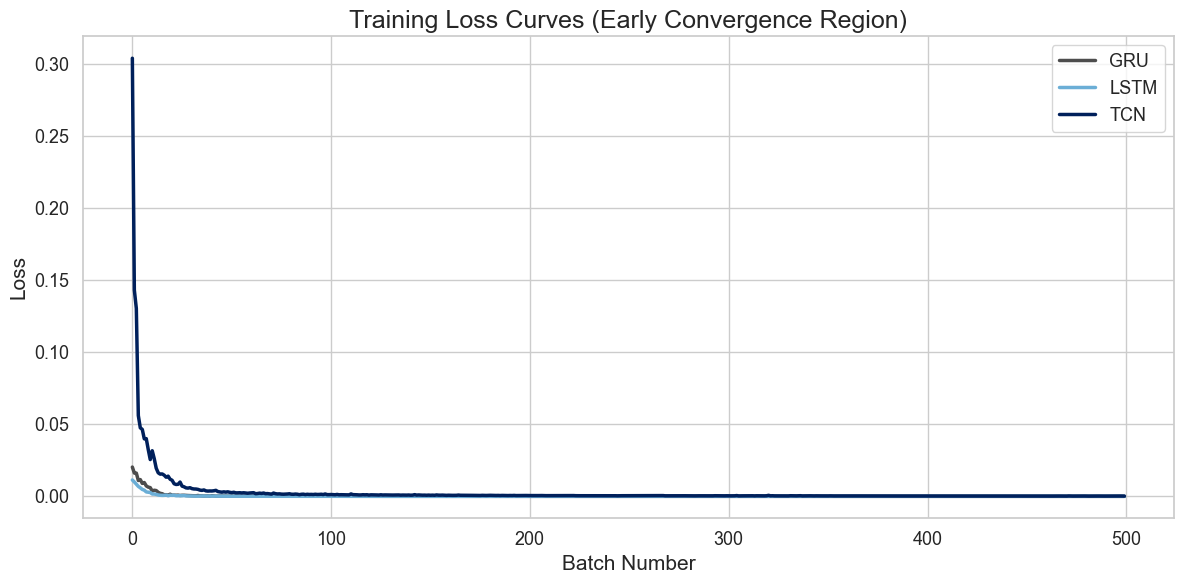

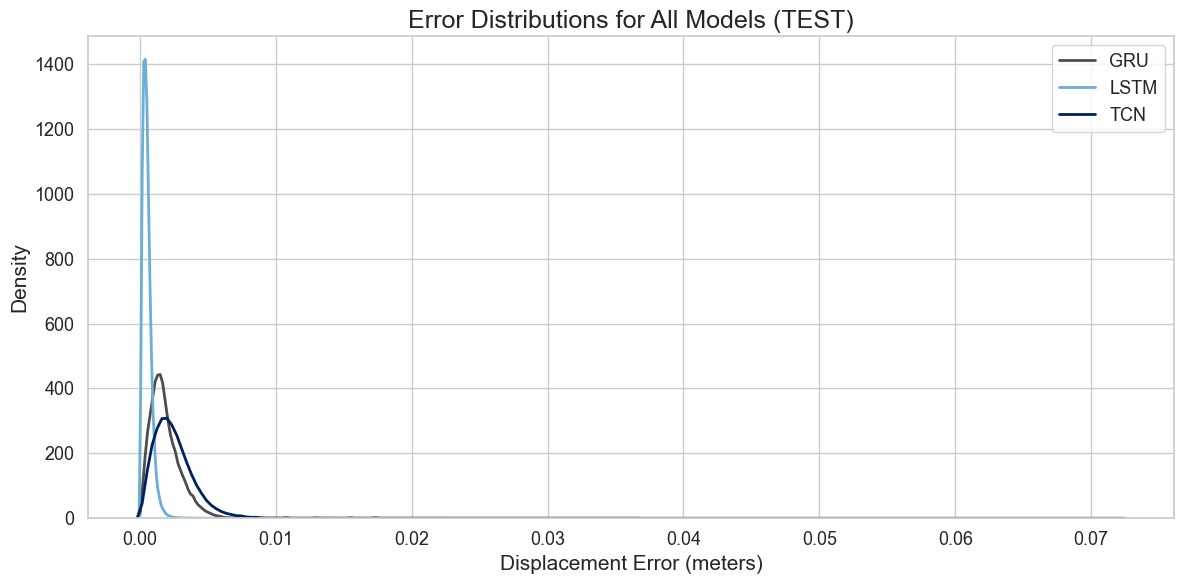

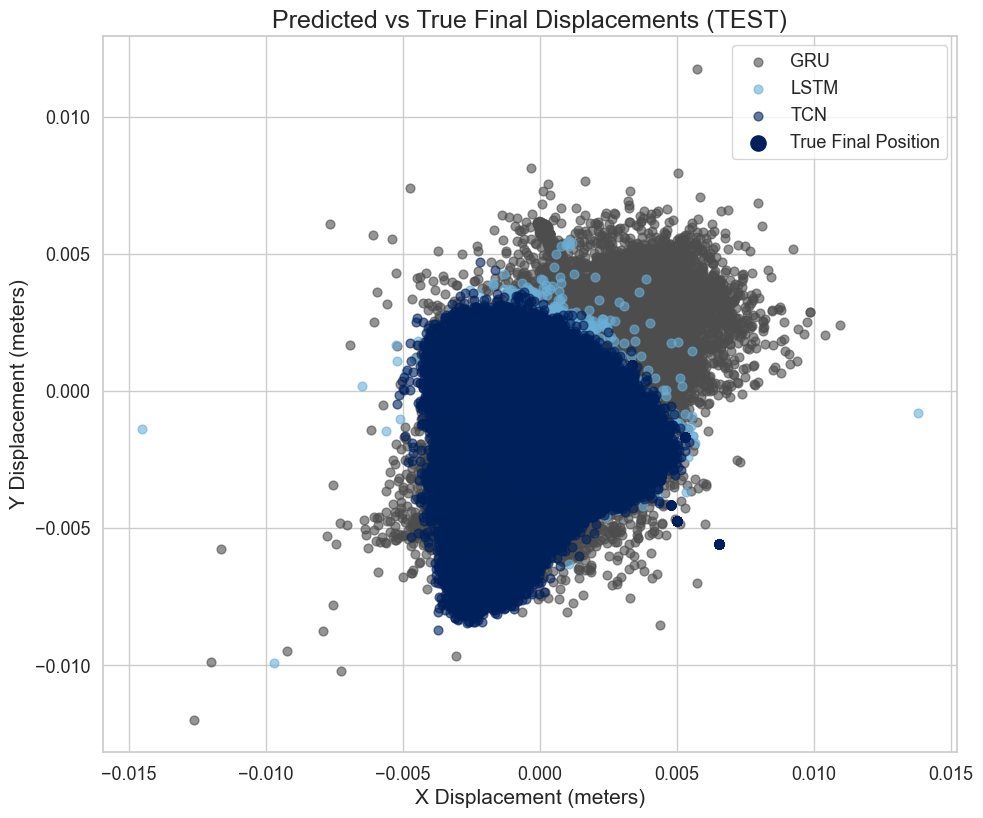

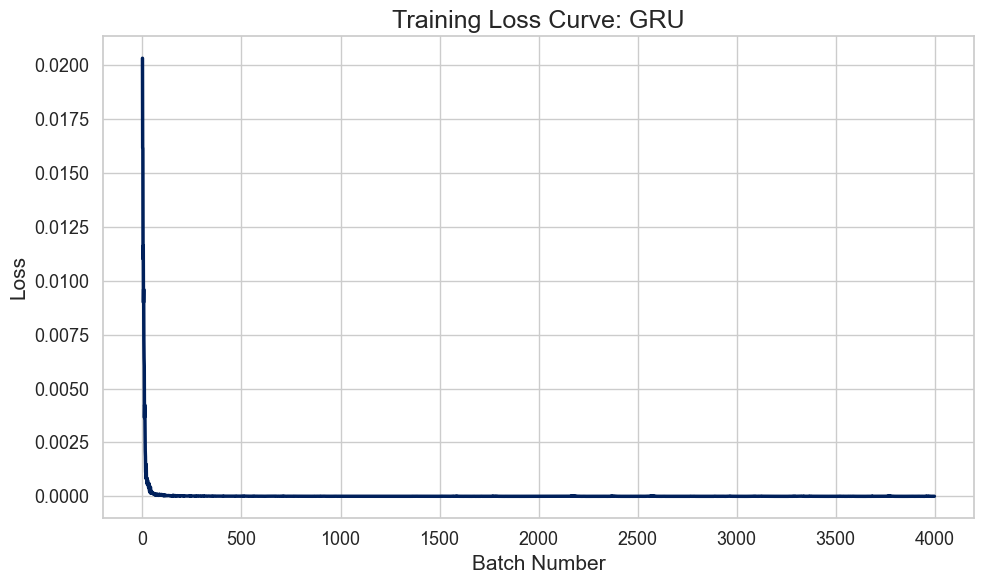

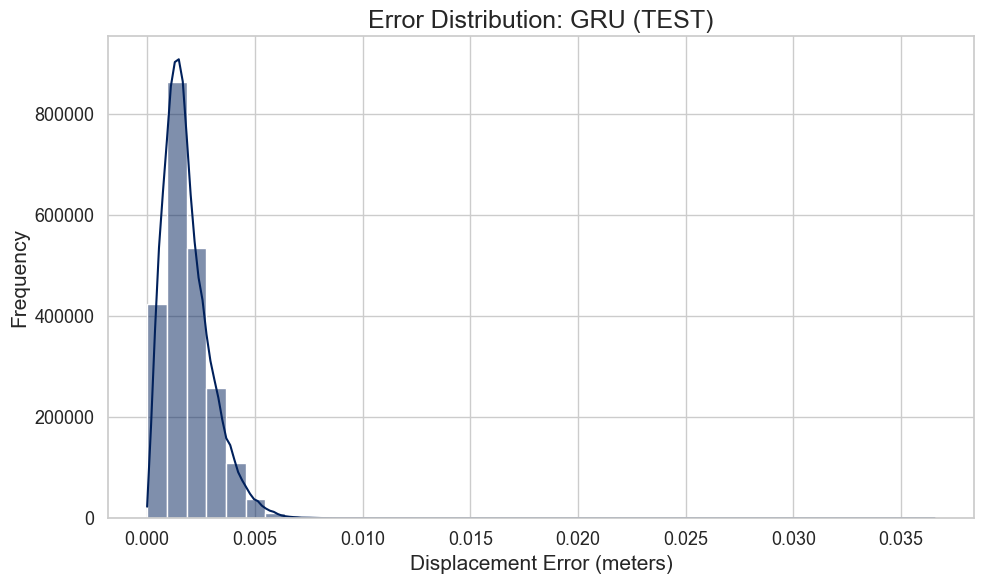

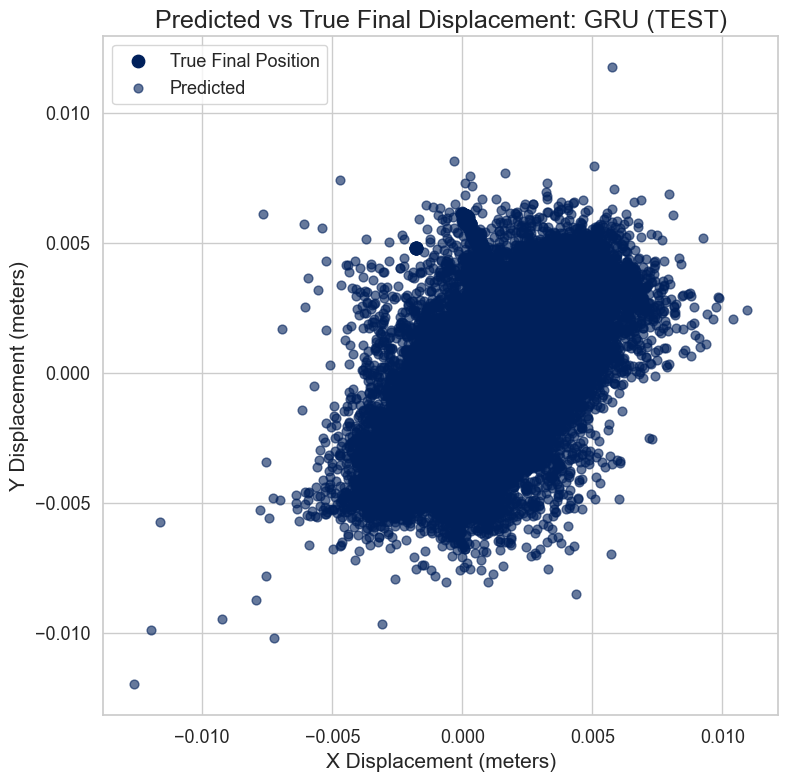

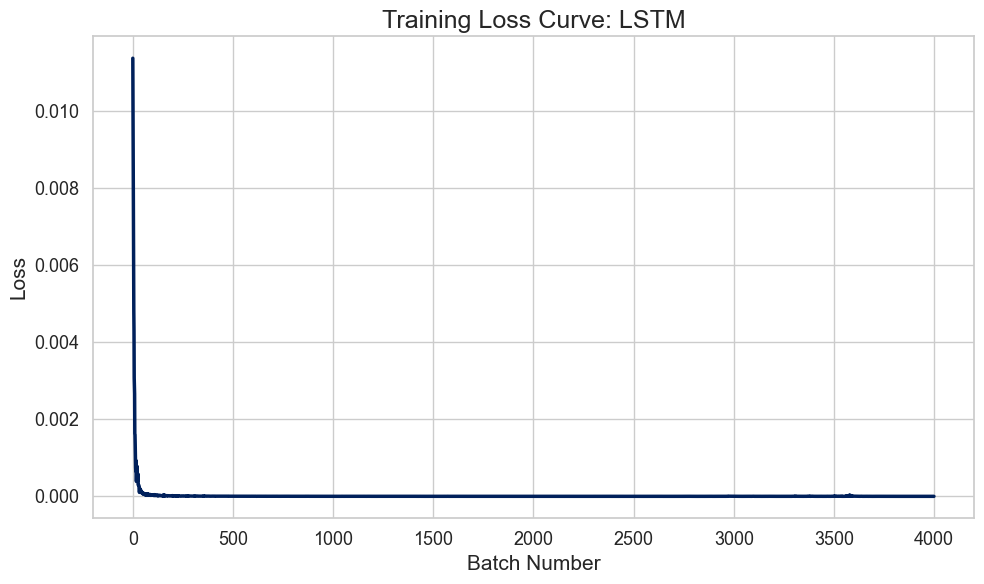

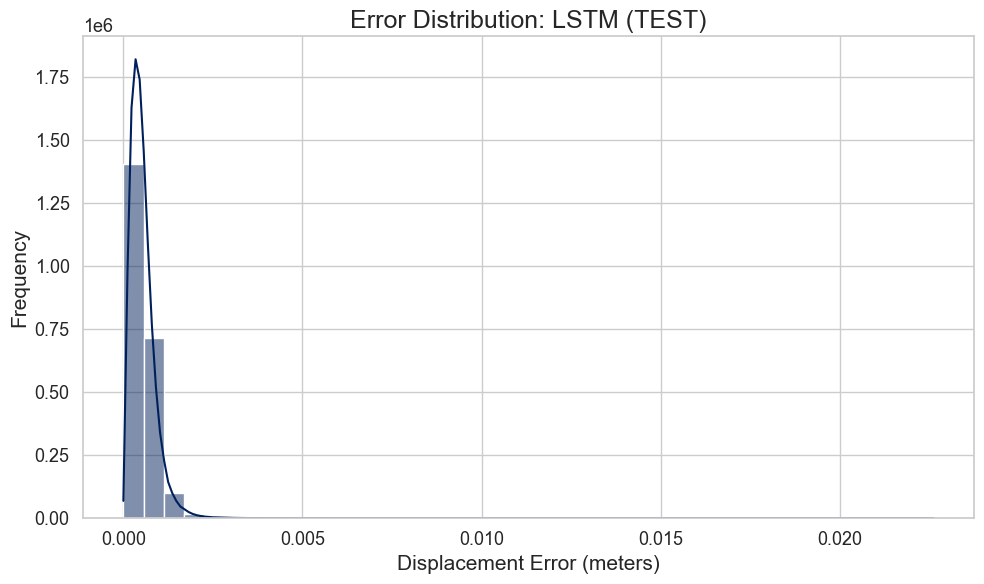

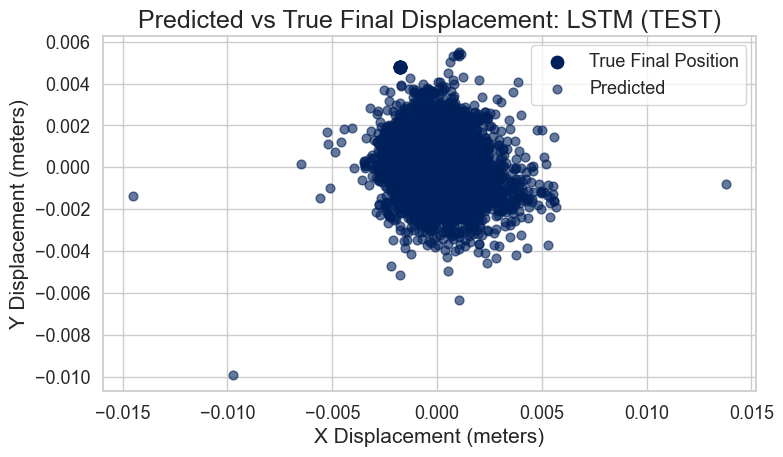

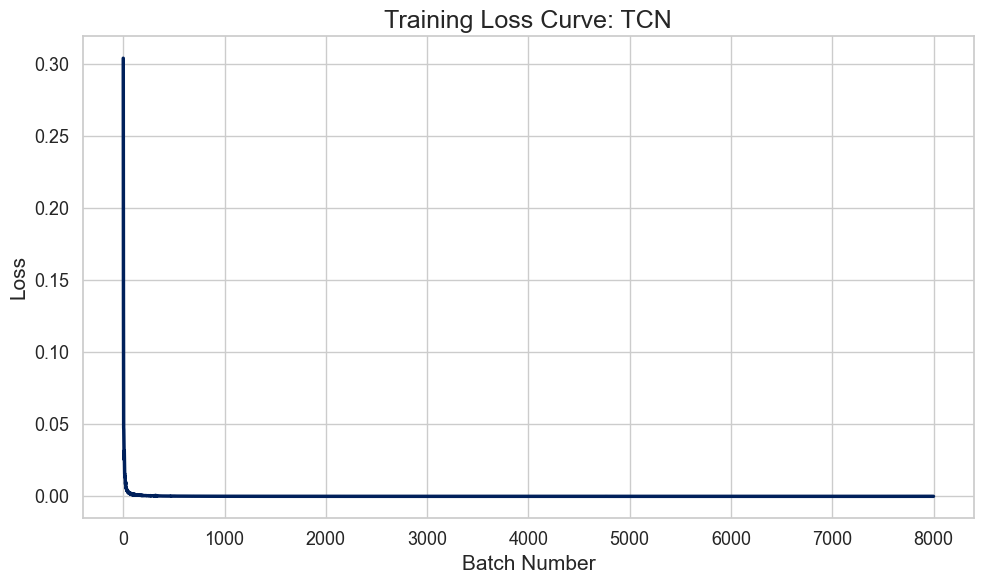

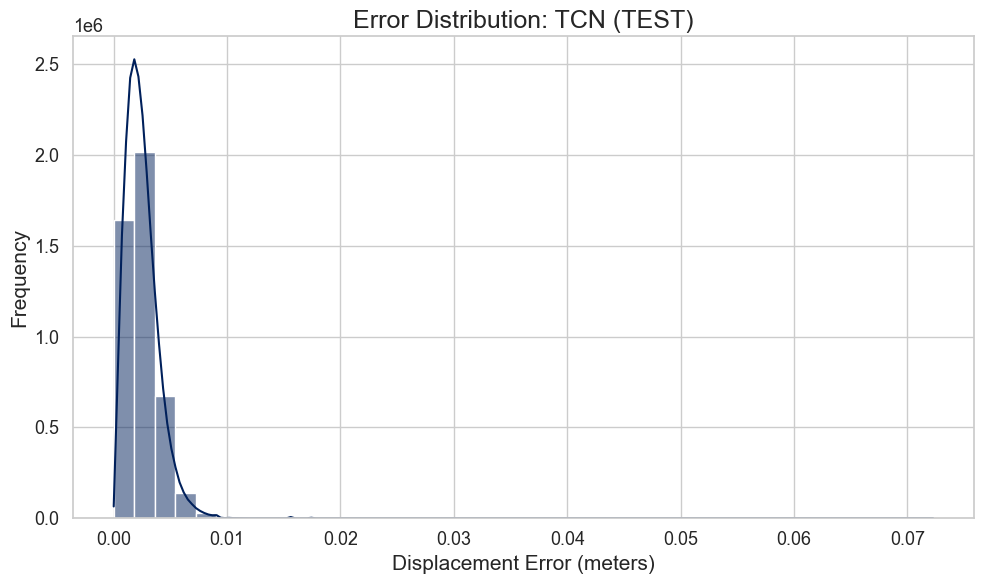

C:\Users\gb630\AppData\Local\Temp\ipykernel_29436\33278536.py:15: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\gb630\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


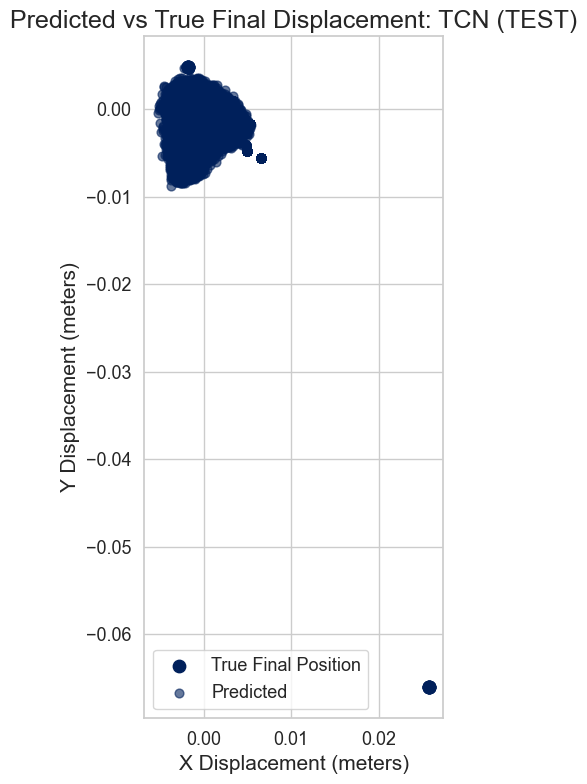

In [ ]:
# Results section figures
plot_all_loss_curves()
plot_all_error_distributions("TEST")
plot_all_scatter_final_displacements("TEST")

# Additional figures
for model in MODELS:
    plot_loss_curve_individual(model)
    plot_error_distribution_individual(model)
    plot_scatter_individual(model)


In [ ]:
def plot_combined_trajectory_analysis(model, phase="TEST", sample_index=0):
    """
    Multi-panel diagnostic visualization:
    Panel 1: Zoomed overlay of predicted vs true future positions
    Panel 2: Residual error vectors
    Panel 3: Error magnitude bar chart
    """

    # Load predicted + true displacements
    preds, targets = load_predictions(model, phase)
    inputs = np.load(os.path.join(PRED_DIR, f"{model}_{phase}_inputs.npy"))

    # Last observed absolute position
    last_pos = inputs[sample_index][-1, 0:2]

    # Convert displacements → absolute positions
    pred_positions = last_pos + preds[sample_index]
    true_positions = last_pos + targets[sample_index]

    # Error vectors + magnitudes
    errors = pred_positions - true_positions
    error_mags = np.linalg.norm(errors, axis=1)

    # Compute zoom bounds
    x_all = np.concatenate([true_positions[:, 0], pred_positions[:, 0]])
    y_all = np.concatenate([true_positions[:, 1], pred_positions[:, 1]])
    pad = 0.0005
    x_min, x_max = x_all.min() - pad, x_all.max() + pad
    y_min, y_max = y_all.min() - pad, y_all.max() + pad

    # Create multi-panel figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Panel 1 — Zoomed Overlay
    ax = axes[0]
    ax.plot(true_positions[:, 0], true_positions[:, 1],
            marker="o", markersize=10, linestyle="none",
            color=COLOR_TRUE, label="True")
    ax.plot(pred_positions[:, 0], pred_positions[:, 1],
            marker="x", markersize=10, linestyle="none",
            color=COLOR_TCN, label="Pred")

    for i in range(FUTURE_STEPS):
        ax.text(true_positions[i, 0], true_positions[i, 1], f"T{i}", fontsize=9)
        ax.text(pred_positions[i, 0], pred_positions[i, 1], f"P{i}", fontsize=9)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(f"{model} ({phase}) — Zoomed Overlay")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="upper left")

    # Panel 2 — Residual Error Vectors
    ax = axes[1]
    ax.scatter(true_positions[:, 0], true_positions[:, 1],
               color=COLOR_TRUE, s=60, label="True")

    for i in range(FUTURE_STEPS):
        ax.arrow(true_positions[i, 0], true_positions[i, 1],
                 errors[i, 0], errors[i, 1],
                 color=COLOR_TCN, head_width=0.0001,
                 length_includes_head=True)
        ax.text(true_positions[i, 0], true_positions[i, 1], f"{i}", fontsize=9)

    ax.set_title("Residual Error Vectors")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="upper left")

    # Panel 3 — Error Magnitude Bar Chart
    ax = axes[2]
    ax.bar(range(FUTURE_STEPS), error_mags, color=COLOR_TCN)
    ax.set_title("Error Magnitude per Future Step")
    ax.set_xlabel("Future Step")
    ax.set_ylabel("Error (meters)")

    plt.tight_layout()
    plt.show()


In [ ]:
def compare_models_side_by_side(phase="TEST", sample_index=0):
    """
    Run combined trajectory analysis for GRU, LSTM, and TCN
    for the same sample index.
    """
    for model in ["GRU", "LSTM", "TCN"]:
        plot_combined_trajectory_analysis(model, phase, sample_index)


## Residual Error Vectors — Understanding Model Mistakes

This visualization overlays **error vectors** on top of the true future positions.
Each arrow shows how far (and in what direction) the model’s prediction deviates
from the true position.

### Why This Matters
- Reveals directional bias in predictions.
- Shows whether errors grow over time.
- Helps diagnose systematic drift patterns.

### Interpretation
- **Short arrows** → small errors.
- **Consistent arrow direction** → directional bias.
- **Increasing arrow length** → error accumulation across future steps.

## Combined Trajectory Analysis — Multi‑Perspective Diagnostic

This 3‑panel dashboard provides a comprehensive view of model performance for a
single sample:

### Panel 1 — Zoomed Overlay
Shows predicted vs true future positions in absolute coordinate space.

### Panel 2 — Residual Error Vectors
Visualizes directional and magnitude errors for each future step.

### Panel 3 — Error Magnitude Bar Chart
Quantifies error growth across the prediction horizon.

### Why This Matters
- Offers a detailed, multi-angle diagnostic for individual trajectories.
- Helps identify whether errors are random or systematic.
- Useful for debugging model behavior on specific motion patterns.

### Interpretation
- **Overlay alignment** → good trajectory prediction.
- **Arrow direction consistency** → systematic drift.
- **Bar chart slope** → error accumulation over time.

## Side‑by‑Side Model Comparison — Same Sample, Different Architectures

This function runs the combined trajectory analysis for **GRU**, **LSTM**, and
**TCN** using the same sample index. It allows direct visual comparison of how
each model handles identical motion patterns.

### Why This Matters
- Highlights architectural strengths and weaknesses.
- Shows which models generalize better to specific trajectory types.
- Useful for selecting the best model for deployment.

### Interpretation
- **GRU** → good short-range memory.
- **LSTM** → better long-range temporal structure.
- **TCN** → strongest stability due to dilated convolutions + attention.


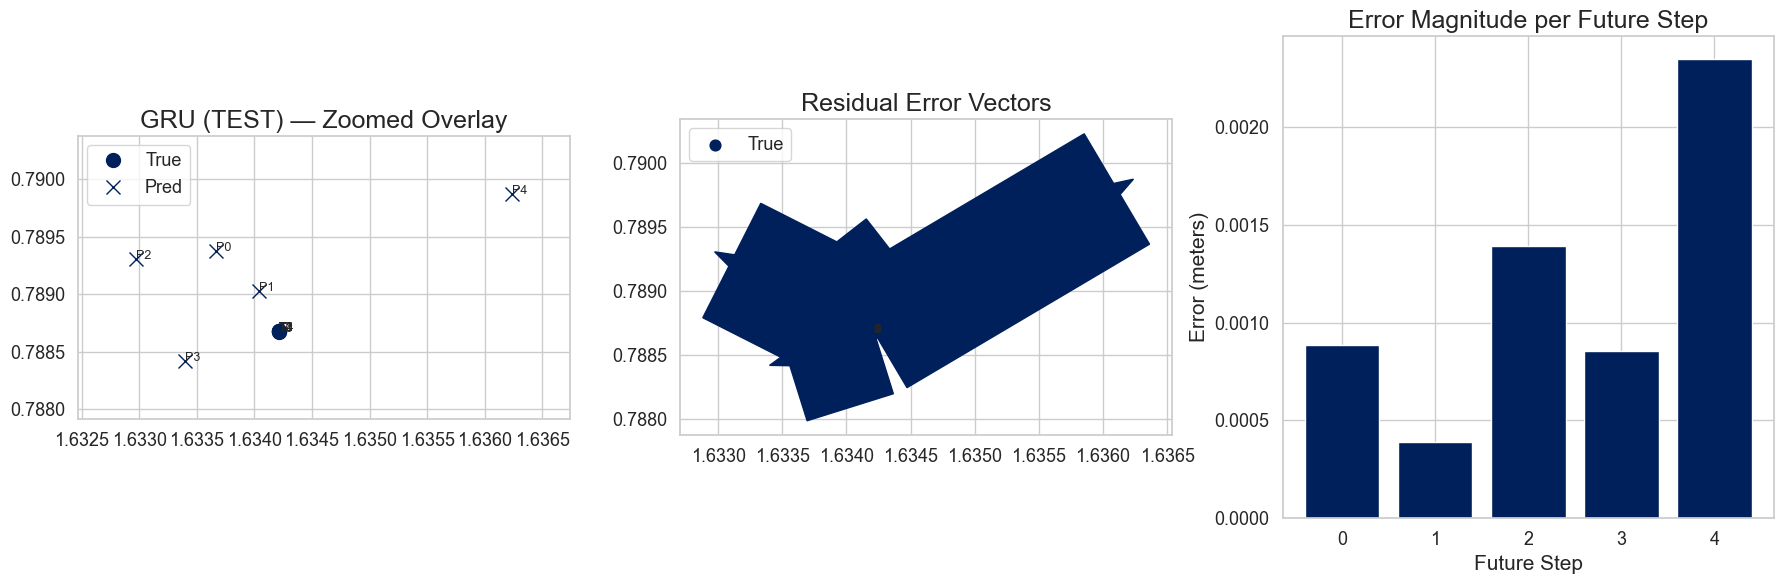

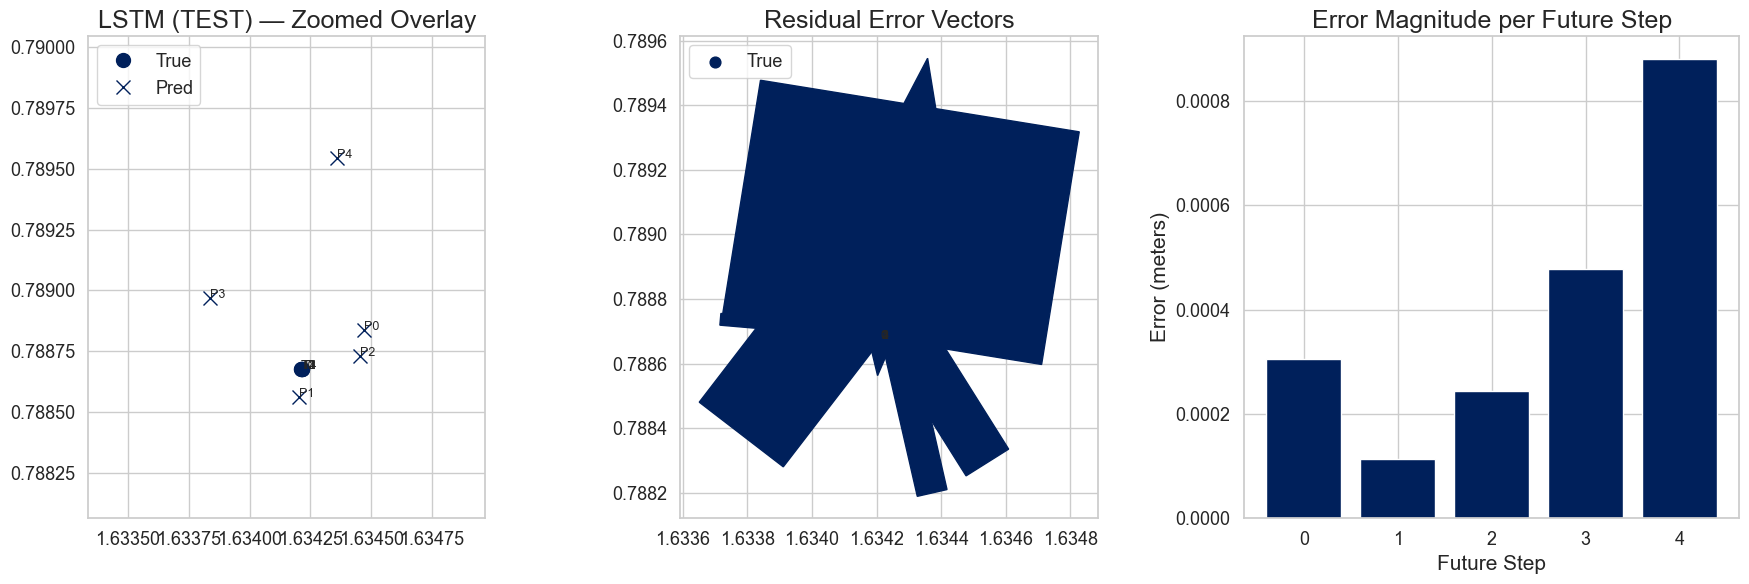

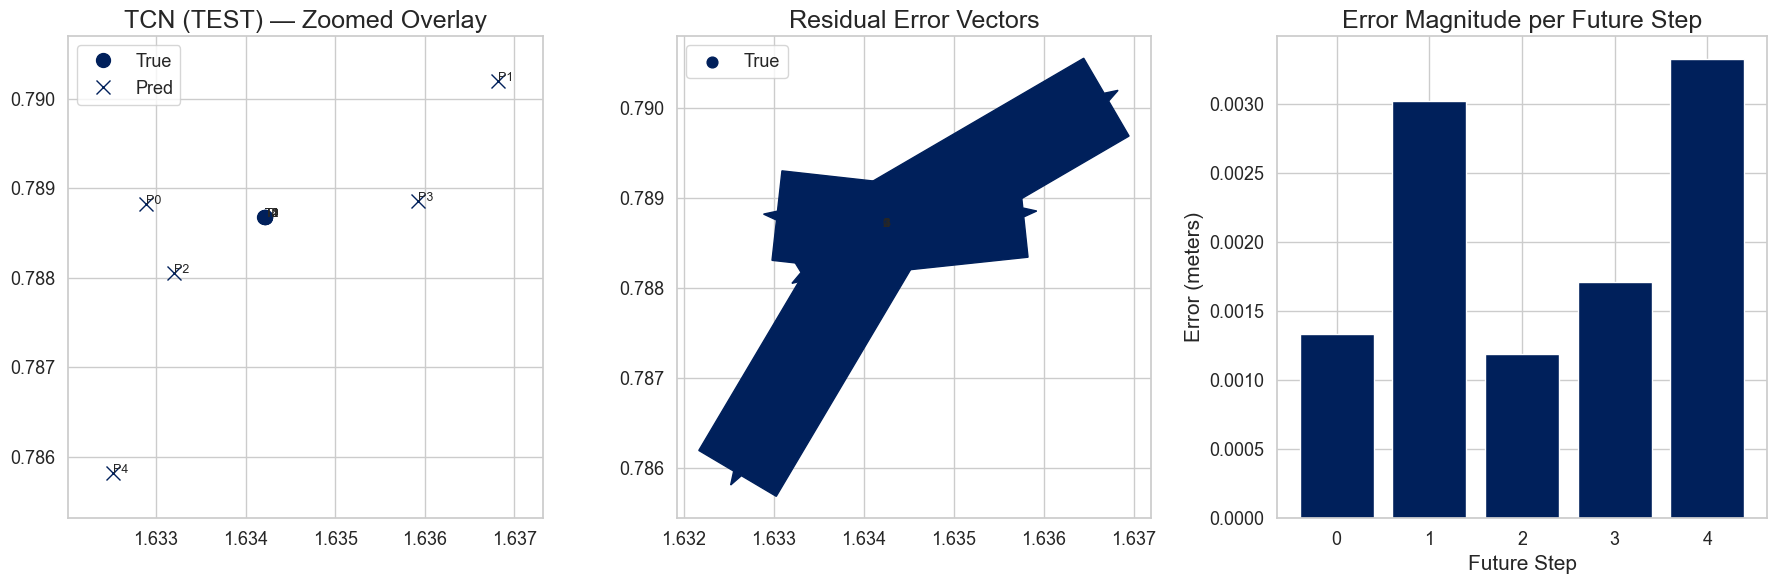

In [ ]:
compare_models_side_by_side("TEST", sample_index=42)


# Model Performance Dashboard — ADE / FDE / MDE

This dashboard summarizes the performance of all three learned models  
(**GRU**, **LSTM**, **TCN**) using three standard trajectory‑forecasting metrics:

### **ADE — Average Displacement Error**
Measures the mean Euclidean error across all predicted future steps.  
Lower ADE indicates better overall multi‑step accuracy.

### **FDE — Final Displacement Error**
Measures the error at the final predicted timestep.  
This is critical for applications where the endpoint matters (e.g., navigation).

### **MDE — Maximum Displacement Error**
Captures the worst‑case error across the prediction horizon.  
Useful for understanding stability and robustness.

---

## How the Dashboard Is Constructed

- We select a set of **representative sample indices** from the TEST set.
- For each model:
  - We load the saved **input windows**, **true future displacements**, and **predicted displacements**.
  - We convert displacements → absolute positions using the last observed point.
  - We compute ADE, FDE, and MDE for each selected sample.
- We average the metrics across all selected samples.
- The final bar chart shows a **side‑by‑side comparison** of all models.

---

## Why This Visualization Matters

This dashboard provides a **high‑level, quantitative comparison** of model performance:

- **GRU** often performs well on short‑range temporal dependencies.  
- **LSTM** may capture longer‑range structure due to gating mechanisms.  
- **TCN** leverages dilated convolutions + attention, often improving stability.

By comparing ADE, FDE, and MDE together, we get a complete picture of:

- Overall accuracy  
- Endpoint precision  
- Worst‑case behavior  

---

## Interpretation

- **Lower bars = better performance.**
- If a model has:
  - Low ADE → good general forecasting  
  - Low FDE → strong final‑step accuracy  
  - Low MDE → stable predictions without large spikes  

Then it is performing well across the board.

---

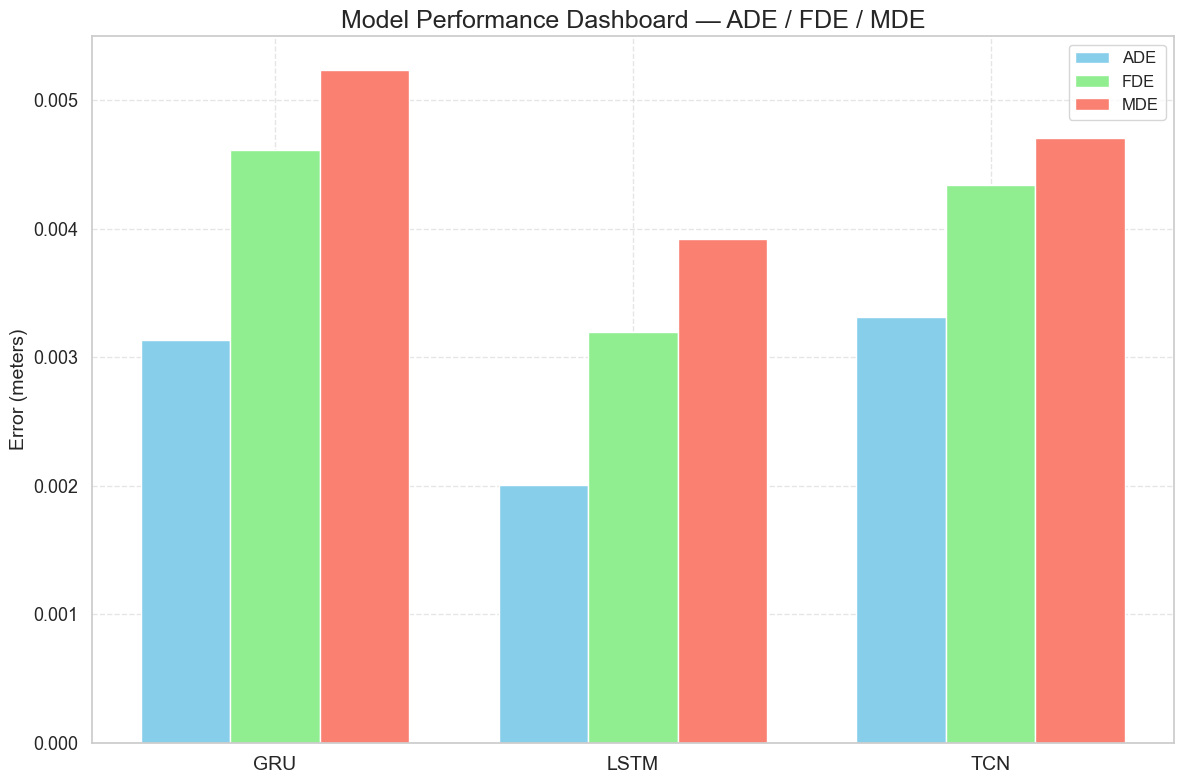

In [ ]:
# ============================================================
# DASHBOARD: ADE / FDE / MDE Summary Across All Samples
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

# --- Project paths ---
# Build absolute paths to the artifact directories where predictions,
# inputs, and targets were saved during model evaluation.
BASE_DIR     = os.path.abspath(os.path.join(os.getcwd(), "..", "src"))
ARTIFACT_DIR = os.path.join(BASE_DIR, "artifacts")
PRED_DIR     = os.path.join(ARTIFACT_DIR, "predictions")

# Models to evaluate
models = ["GRU", "LSTM", "TCN"]

# Phase to evaluate (VAL or TEST)
phase = "TEST"

# --- Choose sample indices ---
# These indices correspond to specific windows from the TEST set.
# They were selected manually based on interesting trajectories.
sample_indices = [343034, 146333, 343036, 343037, 146334, 146335]

# --- Metric functions ---
def ADE(pred, true):
    """
    Average Displacement Error:
    Mean Euclidean distance across all future steps.
    """
    return np.linalg.norm(pred - true, axis=1).mean()

def FDE(pred, true):
    """
    Final Displacement Error:
    Euclidean distance at the last future step.
    """
    return np.linalg.norm(pred[-1] - true[-1])

def MDE(pred, true):
    """
    Maximum Displacement Error:
    Largest Euclidean error across all future steps.
    """
    return np.linalg.norm(pred - true, axis=1).max()

# --- Collect metrics ---
# Structure:
# metrics = {
#   "GRU":  {"ADE": [...], "FDE": [...], "MDE": [...]},
#   "LSTM": {...},
#   "TCN":  {...}
# }
metrics = {m: {"ADE": [], "FDE": [], "MDE": []} for m in models}

for m in models:
    # Load saved predictions, targets, and input windows
    inputs  = np.load(os.path.join(PRED_DIR, f"{m}_{phase}_inputs.npy"))
    targets = np.load(os.path.join(PRED_DIR, f"{m}_{phase}_targets.npy"))
    preds   = np.load(os.path.join(PRED_DIR, f"{m}_{phase}_preds.npy"))

    # Compute metrics for each selected sample index
    for idx in sample_indices:
        input_window = inputs[idx]       # [20 timesteps, 6 features]
        true_future  = targets[idx]      # [5 future steps, 2 coords]
        pred_future  = preds[idx]        # [5 future steps, 2 coords]

        # Convert displacements → absolute positions
        last_pos = input_window[-1, 0:2]
        true_abs = last_pos + true_future
        pred_abs = last_pos + pred_future

        # Append metrics
        metrics[m]["ADE"].append(ADE(pred_abs, true_abs))
        metrics[m]["FDE"].append(FDE(pred_abs, true_abs))
        metrics[m]["MDE"].append(MDE(pred_abs, true_abs))

# --- Compute averages across selected samples ---
avg_ADE = [np.mean(metrics[m]["ADE"]) for m in models]
avg_FDE = [np.mean(metrics[m]["FDE"]) for m in models]
avg_MDE = [np.mean(metrics[m]["MDE"]) for m in models]

# ============================================================
# Plot Dashboard (Single Graph)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(len(models))   # [0, 1, 2]
width = 0.25                 # width of each bar group

# Plot grouped bars for ADE, FDE, MDE
ax.bar(x - width, avg_ADE, width, label="ADE", color="skyblue")
ax.bar(x,         avg_FDE, width, label="FDE", color="lightgreen")
ax.bar(x + width, avg_MDE, width, label="MDE", color="salmon")

# Axis labels and styling
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=14)
ax.set_ylabel("Error (meters)", fontsize=14)
ax.set_title("Model Performance Dashboard — ADE / FDE / MDE", fontsize=18)
ax.legend(fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()
